# Computational Modelling of BC Wildfires
<br> Group 33: 301byte
<br> Group members: Arnav Dhablania, Antarip Kashyap
<br> STAT 301
<br> April 10, 2026

In [2]:
devtools::install_github("diverse-data-hub/diversedata")

Skipping install of 'diversedata' from a github remote, the SHA1 (4d9ebacf) has not changed since last install.
  Use `force = TRUE` to force installation



In [3]:
library(diversedata)
library(tidyverse)
library(dplyr)
library(broom)
library(ggplot2)
library(AER)
library(modelr)
library(glmnet)
library(car)
library(leaps)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
✔ readr     2.1.5     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: car

Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:purrr’:

    some


The following object is masked from ‘package:dplyr’:

    recode


Loading required package: lmtest

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loading required package: sandwich

Loading required package: survival


Attaching package: ‘modelr’


The foll

## (2) Introduction

other introduction stuff - first question w'ere

meow

# (3) Methods and Results

## (a) Data

### (1) Data Description

We begin by previewing the dataset and its provided description. 

In [4]:
?wildfire

wildfire {diversedata},R Documentation


We begin by previewing the dataset and its provided description. 

In [5]:
data("wildfire")
head(wildfire)
dim(wildfire)

year,fire_number,current_size,size_class,latitude,longitude,fire_origin,general_cause,responsible_group,activity_class,⋯,ia_arrival_at_fire_date,ia_access,fire_fighting_start_date,fire_fighting_start_size,bucketing_on_fire,first_bh_date,first_bh_size,first_uc_date,first_uc_size,first_ex_size_perimeter
<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<dttm>,<chr>,<dttm>,<dbl>,<chr>,<dttm>,<dbl>,<dttm>,<dbl>,<dbl>
2006,PWF001,0.10,A,56.25,-117.18,Land Owner,Resident,Resident,Grass,⋯,NA,Unknown,NA,0.02,Unknown,2006-04-02 22:00:00,0.01,2006-04-02 22:00:00,0.01,0.10
2006,EWF002,0.20,B,53.61,-115.92,Fire Department,Incendiary,Others,Lighting Fires,⋯,NA,Unknown,NA,0.02,Unknown,2006-04-03 13:20:00,0.20,2006-04-03 13:20:00,0.20,0.20
2006,EWF001,0.50,B,53.61,-115.59,Fire Department,Incendiary,Others,Lighting Fires,⋯,NA,Unknown,NA,0.02,Unknown,2006-04-03 13:23:00,0.50,2006-04-03 13:23:00,0.50,0.50
2006,EWF003,0.01,A,53.61,-115.61,Industry,Incendiary,Others,Lighting Fires,⋯,NA,Unknown,NA,0.02,Unknown,2006-04-03 14:08:00,0.01,2006-04-03 14:08:00,0.01,0.01
2006,PWF002,0.10,A,56.25,-117.05,Fire Department,Other Industry,Employees,Refuse,⋯,NA,Unknown,NA,0.02,Unknown,2006-04-03 19:57:00,0.10,2006-04-03 20:19:00,0.10,0.10
2006,CWF001,0.20,B,51.15,-115.03,Fire Department,Resident,Resident,Unclassified,⋯,NA,Unknown,NA,0.02,Unknown,2006-04-02 16:00:01,0.20,2006-04-02 16:00:01,0.20,0.20


[1] 26551    35

- The above shows the 35 variables present in the wildfire dataset, with 26551 observations. The table below shows the names and types of the available variables in wildfire. 

In [6]:
variables_table <- tibble(
    name = names(wildfire),
    data_Type = sapply(wildfire, class))

# head(variables_table)

print(variables_table, n = 35)

# A tibble: 35 × 2
   name                         data_Type   
   <chr>                        <named list>
 1 year                         <chr [1]>   
 2 fire_number                  <chr [1]>   
 3 current_size                 <chr [1]>   
 4 size_class                   <chr [1]>   
 5 latitude                     <chr [1]>   
 6 longitude                    <chr [1]>   
 7 fire_origin                  <chr [1]>   
 8 general_cause                <chr [1]>   
 9 responsible_group            <chr [1]>   
10 activity_class               <chr [1]>   
11 true_cause                   <chr [1]>   
12 fire_start_date              <chr [2]>   
13 detection_agent_type         <chr [1]>   
14 detection_agent              <chr [1]>   
15 assessment_hectares          <chr [1]>   
16 fire_spread_rate             <chr [1]>   
17 fire_type                    <chr [1]>   
18 fire_position_on_slope       <chr [1]>   
19 weather_conditions_over_fire <chr [1]>   
20 temperature                  <chr


- According to the provided description, the data was collected under the Alberta Open Government License, with the source of the Government of Alberta.
- By the linked licensing, the data source and citation requested by the government of Alberta includes permissions, such as being able to

"Copy, modify, publish, translate, adapt, distribute or otherwise use the Information in any medium, mode or format for any lawful purpose."
- Specifically, with the requirements to cite as follows: 
"Acknowledge the source of the Information by including any attribution statement specified by the Information Provider(s) and, where possible, provide a link to this licence.
If the Information Provider does not provide a specific attribution statement, or if you are using Information from several Information Providers and multiple attributions are not practical for your product or application, you must use the following attribution statement:

                 Contains information licensed under the Open Government Licence – Alberta.

The terms of this licence are important, and if you fail to comply with any of them, the rights granted to you under this licence, or any similar licence granted by the Information Provider, will end automatically."

<br> With these acknowledgements and citations, this project complies with the necessary requirements outlined in the Open Government License - Alberta. This data seems to be collected observationally. 

## b) Exploratory Data Analysis (EDA)

We begin our data analysis and visualization by loading, cleaning, and wrangling our data. We copy our data into a separate variable and preview again. Our use of diversedata library helps ensure our code is reproducible, since the data isn't coming from a local copy. 

In [7]:
wildfire_clean <- wildfire # copy of wildfire
head(wildfire_clean)

year,fire_number,current_size,size_class,latitude,longitude,fire_origin,general_cause,responsible_group,activity_class,⋯,ia_arrival_at_fire_date,ia_access,fire_fighting_start_date,fire_fighting_start_size,bucketing_on_fire,first_bh_date,first_bh_size,first_uc_date,first_uc_size,first_ex_size_perimeter
<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<dttm>,<chr>,<dttm>,<dbl>,<chr>,<dttm>,<dbl>,<dttm>,<dbl>,<dbl>
2006,PWF001,0.10,A,56.25,-117.18,Land Owner,Resident,Resident,Grass,⋯,NA,Unknown,NA,0.02,Unknown,2006-04-02 22:00:00,0.01,2006-04-02 22:00:00,0.01,0.10
2006,EWF002,0.20,B,53.61,-115.92,Fire Department,Incendiary,Others,Lighting Fires,⋯,NA,Unknown,NA,0.02,Unknown,2006-04-03 13:20:00,0.20,2006-04-03 13:20:00,0.20,0.20
2006,EWF001,0.50,B,53.61,-115.59,Fire Department,Incendiary,Others,Lighting Fires,⋯,NA,Unknown,NA,0.02,Unknown,2006-04-03 13:23:00,0.50,2006-04-03 13:23:00,0.50,0.50
2006,EWF003,0.01,A,53.61,-115.61,Industry,Incendiary,Others,Lighting Fires,⋯,NA,Unknown,NA,0.02,Unknown,2006-04-03 14:08:00,0.01,2006-04-03 14:08:00,0.01,0.01
2006,PWF002,0.10,A,56.25,-117.05,Fire Department,Other Industry,Employees,Refuse,⋯,NA,Unknown,NA,0.02,Unknown,2006-04-03 19:57:00,0.10,2006-04-03 20:19:00,0.10,0.10
2006,CWF001,0.20,B,51.15,-115.03,Fire Department,Resident,Resident,Unclassified,⋯,NA,Unknown,NA,0.02,Unknown,2006-04-02 16:00:01,0.20,2006-04-02 16:00:01,0.20,0.20


After cleaning, we check the percentage of missing values for the variables in the original dataset.

In [8]:
missing_values <- tibble(
    var = names(wildfire), 
    num_missing = colSums(is.na(wildfire)), 
    prop_na = (num_missing / nrow(wildfire))) %>%
    arrange(desc(prop_na)) |>
    filter(prop_na > 0.20)

head(missing_values)

var,num_missing,prop_na
<chr>,<dbl>,<dbl>
ia_arrival_at_fire_date,7703,0.2901209
fire_fighting_start_date,7572,0.2851870


Based on the table above, we see that ia_arrival_at_fire_dat and fire_fighting_start_date variables have a large proportion of missing data (> 20%). This may suggest that we should be prudent when making any inferences using these variables, since it's generalizability may not be very large. We visualize the data to better see discrepancies. 

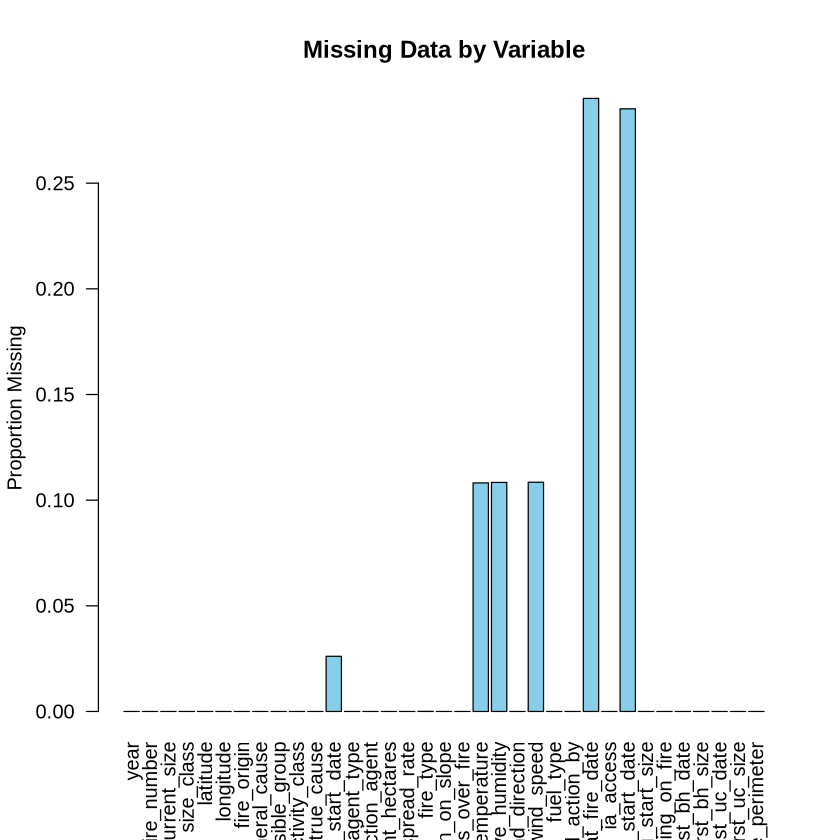

In [9]:
missing_prop <- colMeans(is.na(wildfire_clean))

barplot(
    missing_prop,
    las = 2,  # rotate labels
    col = "skyblue",
    ylab = "Proportion Missing",
    main = "Missing Data by Variable"
)


From the visualization above, we see that action_by and ia_access have a significant proportion of missing data. We look and explore to see if there's any class imbalance in categorical variables in the dataset. We start by filtering the data for the desired variables, and we continue by looking at each variables count, and calculate its proportion. 

In [10]:
cat_imbalance_var <- wildfire_clean |>
    count(general_cause) |>
    mutate(prop = n/sum(n)) |>
    arrange(desc(prop))

cat_imbalance_var

general_cause,n,prop
<chr>,<int>,<dbl>
Lightning,9292,0.3499679861
Recreation,5730,0.2158110806
Resident,4442,0.1673006666
Incendiary,2310,0.0870023728
Power Line Industry,1429,0.0538209484
Undetermined,954,0.0359308501
Agriculture Industry,653,0.0245941772
Forest Industry,491,0.0184927121
Oil & Gas Industry,467,0.0175887914


Lightning appears to be the dominant variable in the dataset at 35%, followed by Recreation and Resident at 22% and 17% respectively. Finally, we visualize the data in a way that will help us explore the data or address the question. To best understand our data, I use a bar plot visualization of the correlation of the numeric varables with the current fire size. 

## ADD SECOND VISUALIZATION HERE

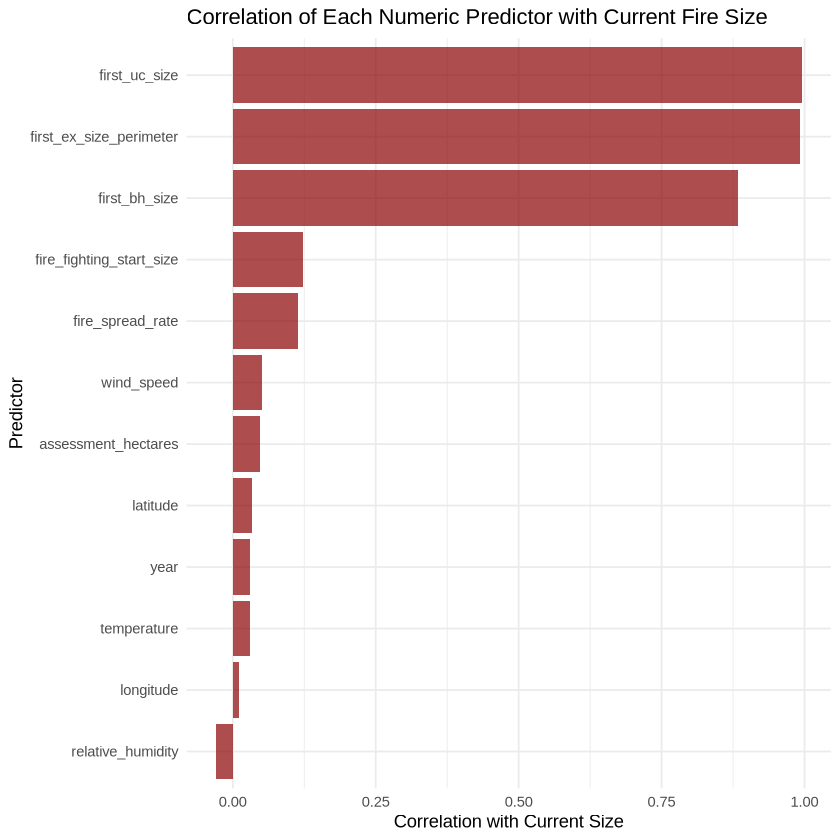

In [13]:
num_data <- wildfire %>%
  select(where(is.numeric)) %>%
  filter(!is.na(current_size)) %>%
  na.omit()

cors <- cor(num_data)[, "current_size"]

cor_df <- data.frame(
  variable = names(cors),
  correlation = as.numeric(cors)
) %>%
  filter(variable != "current_size") %>%
  arrange(desc(abs(correlation)))

ggplot(cor_df, aes(x = reorder(variable, correlation), y = correlation)) +
  geom_col(fill = "darkred", alpha = 0.7) +
  coord_flip() +
  labs(
    title = "Correlation of Each Numeric Predictor with Current Fire Size",
    x = "Predictor",
    y = "Correlation with Current Size"
  ) +
  theme_minimal()

## c) Methods: Plan

(b) One method to answer my question of interest, which is how weather conditions might be associated with the rate at which wildfires spread, is through an interactive Multiple Linear Regression model, predicting for the continuous variable fire_spread_rate. I'll be using forward stepwise method to do variable selection to build an effective model. 
<br> This method was chosen to account for the variable type (continuous), so MLR is needed to correctly make associations. Since I'm investigating weather conditions, these covariates often work together rather than independently. As a result, an interactive model may be more applicable than an additive MLR model, which is more relevant to variables that are independently associated. In comparison, an interactive model may be more reflective of the real-world behaviour of wildfires. It's also important to note that the model identifies associations, rather than any causal effects. 

(c) For an MLR model, a few assumptions are made, including:
- Linearity: that the relationship between the predictors and the response variable are approximately linear (or can be transformed to be linear. To check this assumption of linearity, fitted values can be plotted against the residuals, in order to identify any non-linear patterns. Additionally, transformations of the covariates can change the interpretation of the model.  
- Independence of observations: that observations in the wildfire dataset are independent of each other. To diagnose this, a residuals plot can be useful to check for any possible correlations. Violation of this assumption could mean that confidence intervals and calculated p-values are no longer valid. 
- Normal distribution: that errors are approximately normally distributed. This can be mitigated if sample size is large enough (CLT), and by using bootstrapping. To diagnose, Q-Q plots and histograms of the residuals can be used. 
- Homoscedasticity: errors are roughly constant (consistent variance), and don't form "tube shapes" in its distribution. A fitted vs residuals plot is also useful in detecting hetereoscedasticity, and violations of this assumption could again mean confidence intervals and p-values are no longer valid. To address this, we can use variance stabilizing transformations of the response, or to use Weighted Least Squares to see how variance changes with the response. 
- Lack of multicollinearity: that predictors should not be severely correlated with one another (usually, in this course, VIF over 5 or 10). Violating this could mean that standard errors of our estimates are inflated, making confidence intervals larger and facilitating less opportunities to reject the null hypothesis. As mentioned early, VIF can be used to diagnose multicollinearity, which checks the increase in the standard error of the coefficients when fitted alone compared to when fitted with all other variables.

Potential limitations/weaknesses also include
- Fire spread rate/the relatinoship might not be linear - meaning that an MLR model may oversimplify the regression
- Confounding variables may exist, like  fire_type or weather_conditions_over_fire, which may change the interpretations/interpretability of the model coefficients, especially where causality may be related
- Categorical imbalance - since it's an interactive model, will affect how the coefficients are calculated